In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from pathlib import Path
from collections import Counter
from itertools import chain
from tqdm.auto import tqdm

ROOT = Path.cwd().parent.resolve()
docs_path = ROOT / "data" / "wikIR1k" / "documents.csv"
stopwords_path = ROOT / "data" / "nltk" / "eng_stopwords.txt"

with open(stopwords_path, "r", encoding="utf-8") as f:
    stopwords = {line.strip() for line in f if line.strip()}

/opt/homebrew/Caskroom/miniforge/base/envs/ir_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import spacy
from nltk.stem import PorterStemmer
from transformers import AutoTokenizer

---
# Basic collection stats

In [4]:
def print_basic_collection_stats(
    df: pd.DataFrame,
    text_col: str = "text_right",
    id_col: str = "id_right",
    digits: int = 2,
) -> dict:
    required_cols = [id_col, text_col]
    missing_cols = [col for col in required_cols if col not in df.columns]

    assert not missing_cols, f"Missing columns: {missing_cols}"
    assert not df[required_cols].isna().any().any(), f"Missing values found in {required_cols}"
    assert not df[id_col].duplicated().any(), f"Duplicate IDs found in {id_col}"

    tokenized = df[text_col].str.split()
    doc_lengths = tokenized.apply(len)
    words = tokenized.explode()

    stats = {
        "Number of documents": f"{len(df):,}",
        "Collection size (words)": f"{int(doc_lengths.sum()):,}",
        "Average document length (words)": f"{doc_lengths.mean():.{digits}f}",
        "Number of unique words": f"{words.nunique():,}",
        "Average unique word length": f"{words.drop_duplicates().str.len().mean():.{digits}f}",
        "Average word length in collection": f"{words.str.len().mean():.{digits}f}",
    }

    width = max(len(label) for label in stats)

    print("Basic collection statistics")
    print("-" * (width + 20))
    for label, value in stats.items():
        print(f"{label:<{width}} : {value}")

    return stats

In [5]:
df = pd.read_csv(docs_path)
display(df.head())
_ = print_basic_collection_stats(df)

,id_right,text_right
0,1781133,it was used in landing craft during world war ...
1,2426736,after rejecting an offer from cambridge univer...
2,2224122,mat zan coached kuala lumpur fa in 1999 and wo...
3,219642,a barcode is a machine readable optical label ...
4,1728654,since the subordination of the monarchy under ...


Basic collection statistics
-----------------------------------------------------
Number of documents               : 369,721
Collection size (words)           : 73,093,729
Average document length (words)   : 197.70
Number of unique words            : 794,568
Average unique word length        : 7.71
Average word length in collection : 4.80


---
# Frequency list

In [6]:
def highlight_stopwords(row):
    color = "background-color: #1f6f4a; color: white" if row["is_stopword"] else ""
    return [color] * len(row)

In [7]:
tokenized = df["text_right"].str.split()
word_counter = Counter(chain.from_iterable(tokenized))

freq_df = (
    pd.DataFrame(word_counter.items(), columns=["word", "count"])
    .sort_values(["count", "word"], ascending=[False, True], ignore_index=True)
)
freq_df["is_stopword"] = freq_df["word"].isin(stopwords)
freq_df_no_stop = freq_df.loc[~freq_df["is_stopword"]].reset_index(drop=True)

display(freq_df.head(30).style.apply(highlight_stopwords, axis=1))

,word,count,is_stopword
0,the,5311943,True
1,of,2532382,True
2,in,2355417,True
3,and,2231007,True
4,a,1557760,True
5,to,1407261,True
6,was,1078183,True
7,he,685303,True
8,is,676829,True
9,as,661622,True


In [8]:
stopword_occurrences = freq_df.loc[freq_df["is_stopword"], "count"].sum()
total_occurrences = freq_df["count"].sum()
print(
    f"Stopword occurrences: {stopword_occurrences:,} "
    f"({100 * stopword_occurrences / total_occurrences:.2f}% of the collection)"
)

top30 = freq_df.head(30)
top30_non_stopwords = top30.loc[~top30["is_stopword"], ["word", "count"]]
if top30_non_stopwords.empty:
    print("All top-30 most frequent words occur in the stopword list.")
else:
    print("Top-30 words not in the stopword list:")
    display(top30_non_stopwords)

print("Possible expanding of the stopword list:")
display(freq_df.loc[~freq_df["is_stopword"], ["word", "count"]].head(15))


Stopword occurrences: 29,387,785 (40.21% of the collection)
Top-30 words not in the stopword list:


,word,count
22,first,217204
26,also,186055


Possible expanding of the stopword list:


,word,count
22,first,217204
26,also,186055
31,one,157573
36,new,139850
37,two,136427
41,school,119897
43,university,107386
49,time,95373
53,1,89967
54,years,88565


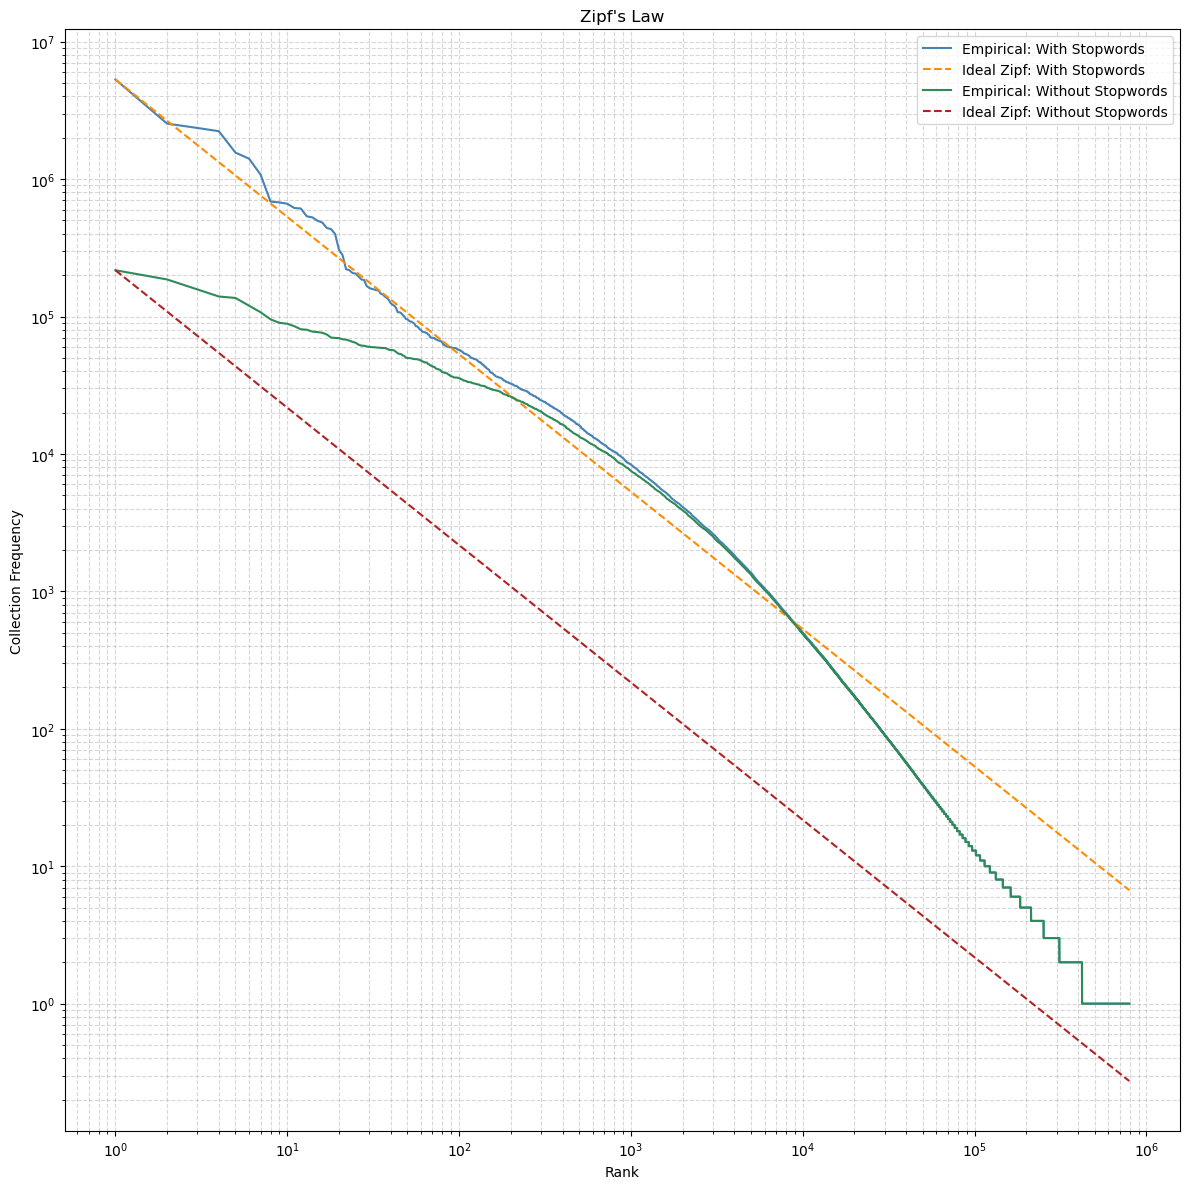

In [9]:
plt.figure(figsize=(12, 12))

for title, data, color, line_color in [
    ("With Stopwords", freq_df, "steelblue", "darkorange"),
    ("Without Stopwords", freq_df_no_stop, "seagreen", "firebrick"),
]:
    ranks = np.arange(1, len(data) + 1)
    freqs = data["count"].to_numpy()
    ideal = freqs[0] / ranks

    plt.loglog(ranks, freqs, color=color, label=f"Empirical: {title}")
    plt.loglog(ranks, ideal, "--", color=line_color, label=f"Ideal Zipf: {title}")

plt.title("Zipf's Law")
plt.xlabel("Rank")
plt.ylabel("Collection Frequency")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
tokenized_docs = df["text_right"].str.split().tolist()

doc_lengths = [len(words) for words in tokenized_docs]
all_words = [word for words in tokenized_docs for word in words]

shuffled_words = all_words.copy()
random.Random(42).shuffle(shuffled_words)

shuffled_docs = []
start = 0
for length in doc_lengths:
    shuffled_docs.append(shuffled_words[start:start + length])
    start += length

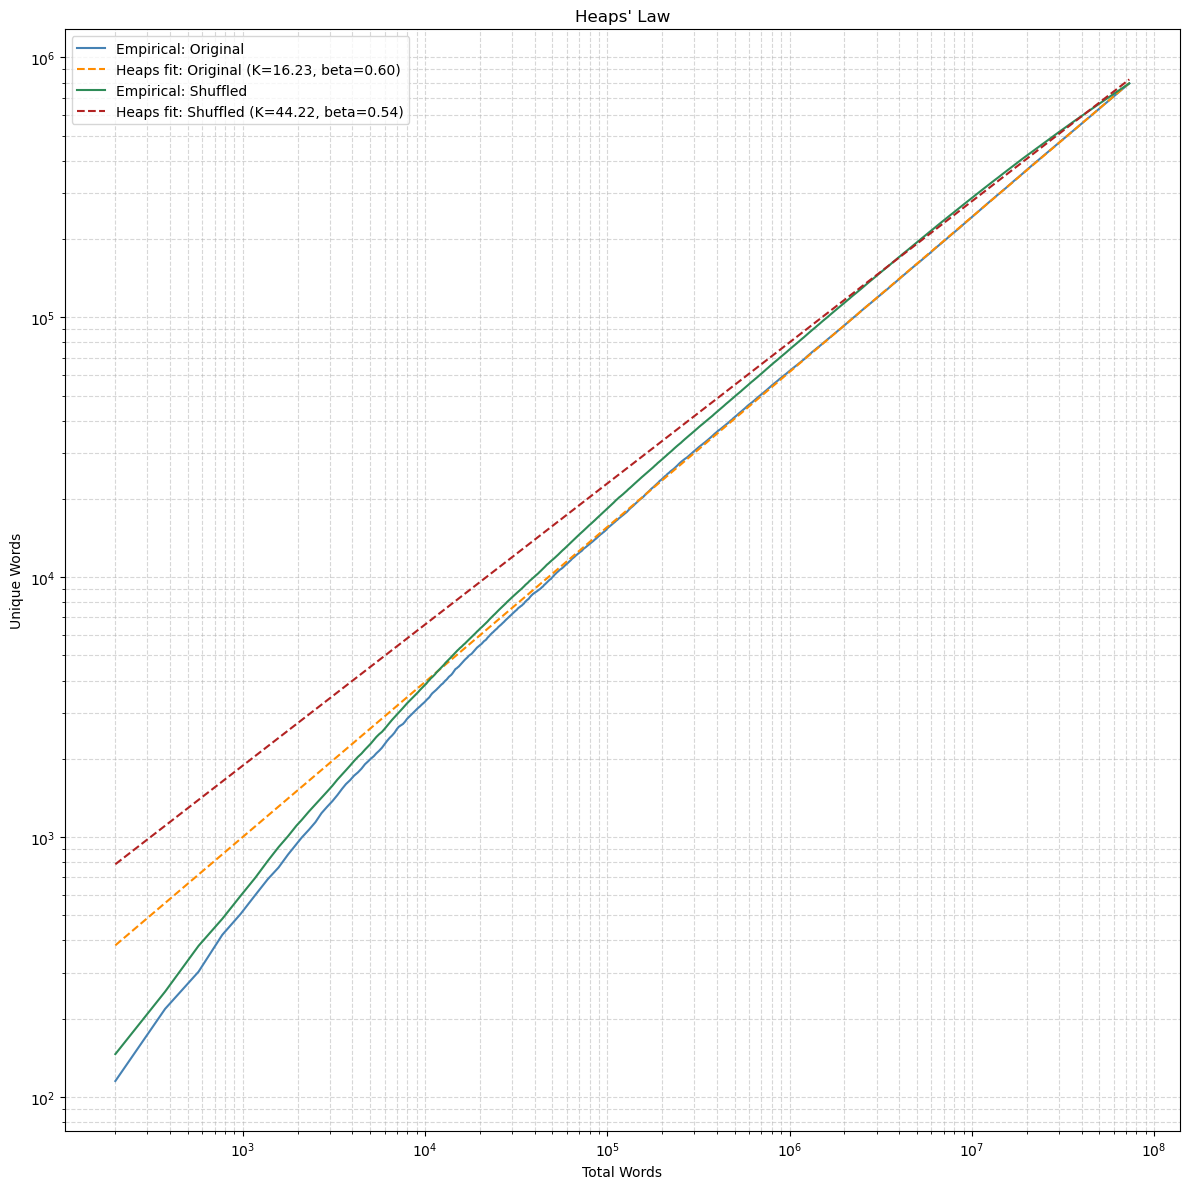

In [11]:
plt.figure(figsize=(12, 12))

for title, docs, color, fit_color in [
    ("Original", tokenized_docs, "steelblue", "darkorange"),
    ("Shuffled", shuffled_docs, "seagreen", "firebrick"),
]:
    total_words = []
    unique_words = []
    seen = set()
    running_total = 0

    for words in docs:
        running_total += len(words)
        seen.update(words)
        total_words.append(running_total)
        unique_words.append(len(seen))

    total_words = np.array(total_words)
    unique_words = np.array(unique_words)

    beta, log_k = np.polyfit(np.log(total_words), np.log(unique_words), 1)
    k = np.exp(log_k)
    fitted = k * total_words**beta

    plt.loglog(total_words, unique_words, color=color, label=f"Empirical: {title}")
    plt.loglog(
        total_words,
        fitted,
        "--",
        color=fit_color,
        label=f"Heaps fit: {title} (K={k:.2f}, beta={beta:.2f})",
    )

plt.title("Heaps' Law")
plt.xlabel("Total Words")
plt.ylabel("Unique Words")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


---
# Frequency list of word bigrams

In [12]:
tokenized_docs = df["text_right"].str.split().tolist()

bigram_dfs = {}

for name, remove_stopwords in [
    ("all", False),
    ("no_stop", True),
]:
    counter = Counter(
        f"{w1}_{w2}"
        for doc in tokenized_docs
        for w1, w2 in zip(doc, doc[1:])
        if not remove_stopwords or (w1 not in stopwords and w2 not in stopwords)
    )

    bigram_dfs[name] = (
        pd.DataFrame(counter.items(), columns=["bigram", "count"])
        .sort_values(["count", "bigram"], ascending=[False, True], ignore_index=True)
    )

bigram_df = bigram_dfs["all"]
bigram_df_no_stop = bigram_dfs["no_stop"]

In [13]:
print("Top 15 bigrams (with stopwords):")
display(bigram_df.head(20))

print("Top 15 bigrams (without stopwords):")
display(bigram_df_no_stop.head(20))

Top 15 bigrams (with stopwords):


,bigram,count
0,of_the,768320
1,in_the,546863
2,to_the,256451
3,at_the,201351
4,and_the,170394
5,on_the,169708
6,he_was,163554
7,as_a,163073
8,for_the,159502
9,by_the,130810


Top 15 bigrams (without stopwords):


,bigram,count
0,united_states,48952
1,new_york,38477
2,high_school,29895
3,world_war,20915
4,war_ii,10432
5,york_city,10401
6,los_angeles,10042
7,two_years,9013
8,new_zealand,8764
9,years_later,7412


---
# Morphological processing

In [14]:
stemmer = PorterStemmer()

stemmed_df = df[["id_right"]].copy()
stemmed_df["text_right"] = [
    " ".join(stemmer.stem(word) for word in text.split())
    for text in tqdm(
        df["text_right"],
        total=len(df)
    )
]
stemmed_df.head()

100%|██████████| 369721/369721 [05:18<00:00, 1160.21it/s]


,id_right,text_right
0,1781133,it wa use in land craft dure world war ii and ...
1,2426736,after reject an offer from cambridg univers sh...
2,2224122,mat zan coach kuala lumpur fa in 1999 and won ...
3,219642,a barcod is a machin readabl optic label that ...
4,1728654,sinc the subordin of the monarchi under parlia...


In [15]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

lemmatized_df = df[["id_right"]].copy()
lemmatized_df["text_right"] = [
    " ".join(token.lemma_ for token in doc if not token.is_space)
    for doc in tqdm(
        nlp.pipe(df["text_right"], batch_size=256),
        total=len(df),
    )
]

lemmatized_df.head()

100%|██████████| 369721/369721 [44:05<00:00, 139.73it/s] 


,id_right,text_right
0,1781133,it be use in landing craft during world war ii...
1,2426736,after reject an offer from cambridge universit...
2,2224122,mat zan coach kuala lumpur fa in 1999 and win ...
3,219642,a barcode be a machine readable optical label ...
4,1728654,since the subordination of the monarchy under ...


In [16]:
bert_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased", use_fast=True)

bert_tokenized_df = df[["id_right"]].copy()
bert_tokenized_df["text_right"] = [
    " ".join(bert_tokenizer.tokenize(text))
    for text in tqdm(
        df["text_right"],
        total=len(df),
    )
]

bert_tokenized_df.head()

100%|██████████| 369721/369721 [01:42<00:00, 3608.85it/s]


,id_right,text_right
0,1781133,it was used in landing craft during world war ...
1,2426736,after rejecting an offer from cambridge univer...
2,2224122,mat za ##n coached kuala lumpur fa in 1999 and...
3,219642,a bar ##code is a machine read ##able optical ...
4,1728654,since the sub ##ord ##ination of the monarchy ...


In [17]:
print("Stemmed collection:")
_ = print_basic_collection_stats(stemmed_df)

print("\nLemmatized collection:")
_ = print_basic_collection_stats(lemmatized_df)

print("\nBERT-tokenized collection:")
_ = print_basic_collection_stats(bert_tokenized_df)

Stemmed collection:
Basic collection statistics
-----------------------------------------------------
Number of documents               : 369,721
Collection size (words)           : 73,093,729
Average document length (words)   : 197.70
Number of unique words            : 684,579
Average unique word length        : 7.34
Average word length in collection : 4.26

Lemmatized collection:
Basic collection statistics
-----------------------------------------------------
Number of documents               : 369,721
Collection size (words)           : 73,106,364
Average document length (words)   : 197.73
Number of unique words            : 758,817
Average unique word length        : 7.64
Average word length in collection : 4.59

BERT-tokenized collection:
Basic collection statistics
-----------------------------------------------------
Number of documents               : 369,721
Collection size (words)           : 81,185,427
Average document length (words)   : 219.59
Number of unique words      

In [21]:
# def custom_path(method):
#     custom_dir = ROOT / "data" / "wikIR1k_custom"
#     custom_dir.mkdir(parents=True, exist_ok=True)
#     return custom_dir / f"{method}_documents.csv"

# lemmatized_df.to_csv(custom_path("lemmatized"), index=False)
# stemmed_df.to_csv(custom_path("stemmed"), index=False)